In [30]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [31]:
df = pd.read_csv("retail_sales_dataset.csv") 
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [32]:
df.columns = ['Transaction_ID','Date','Customer_ID','Gender','Age',
              'Product_Category','Quantity','Price_per_unit','Total_Amount']

In [33]:
df.columns

Index(['Transaction_ID', 'Date', 'Customer_ID', 'Gender', 'Age',
       'Product_Category', 'Quantity', 'Price_per_unit', 'Total_Amount'],
      dtype='object')

In [34]:
df['Date'] = pd.to_datetime(df['Date'])
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['day_of_week'] = df['Date'].dt.dayofweek

In [35]:
df = df.ffill()

In [36]:
df_grouped = df.groupby(['Date','Product_Category'])['Quantity'].sum().reset_index()

In [37]:
df_grouped['lag_1'] = df_grouped['Quantity'].shift(1)
df_grouped['lag_7'] = df_grouped['Quantity'].shift(7)

In [38]:
df_grouped['lead_time'] = np.random.randint(2, 6, size=len(df_grouped))

In [39]:
df_grouped['inventory'] = df_grouped['Quantity'].rolling(7).mean()

In [40]:
df_grouped = df_grouped.dropna()

In [41]:
df_grouped = pd.get_dummies(df_grouped, columns=['Product_Category'])

In [42]:
X = df_grouped.drop(['Quantity','Date'], axis=1)
y = df_grouped['Quantity']

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [44]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [45]:
y_pred = model.predict(X_test)

In [46]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 1.8738435896095655


In [47]:
product_speed = df.groupby('Product_Category')['Quantity'].mean()

print("Fast/Slow Moving Products:\n", product_speed)

Fast/Slow Moving Products:
 Product_Category
Beauty         2.511401
Clothing       2.547009
Electronics    2.482456
Name: Quantity, dtype: float64


In [54]:
df_grouped['avg_demand'] = df_grouped['Quantity'].rolling(7).mean().bfill()

In [55]:
def stock_decision(row):
    if row['inventory'] < row['reorder_point']:
        return "Reorder Needed"
    else:
        return "Stock OK"

df_grouped['stock_status'] = df_grouped.apply(stock_decision, axis=1)

print(df_grouped[['inventory','reorder_point','stock_status']].head())

    inventory  reorder_point    stock_status
7    3.857143      13.571429  Reorder Needed
8    3.142857       5.428571  Reorder Needed
9    3.428571       5.428571  Reorder Needed
10   2.714286       8.142857  Reorder Needed
11   2.857143       8.142857  Reorder Needed


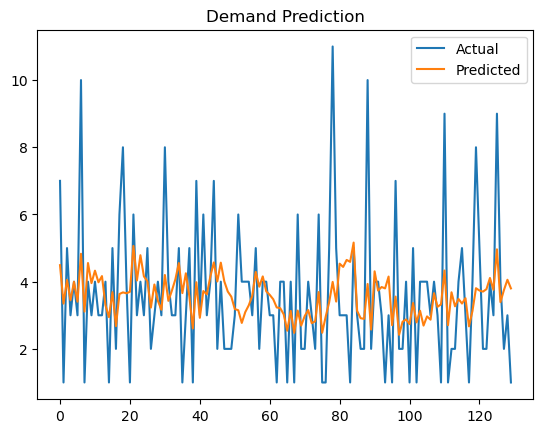

In [56]:
import matplotlib.pyplot as plt

plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("Demand Prediction")
plt.show()